# Notebook 09 — Sensitivity Analysis
Compute station-level weather sensitivity/resilience scores,
rank stations, and produce policy-ready outputs.

## 0. Imports & Load

In [1]:
import pickle
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

ROOT      = Path().resolve().parent
PROCESSED = ROOT / "data" / "processed"
FIGS      = ROOT / "outputs" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

COLORS = {
    "commuter" : "#2196F3",
    "mixed"    : "#FFC107",
    "leisure"  : "#F44336",
}

panel      = pd.read_parquet(PROCESSED / "analysis_panel.parquet")
site_stats = pd.read_parquet(PROCESSED / "site_classification.parquet")
norm       = pd.read_parquet(PROCESSED / "normalized_cycling.parquet")

with open(PROCESSED / "gam_models.pkl", "rb") as fh:
    models = pickle.load(fh)

gam_full     = models["gam_full"]
gam_commuter = models["gam_commuter"]
gam_leisure  = models["gam_leisure"]
le_site      = models["le_site"]

panel_good = panel[panel["low_coverage"] == False].copy()
panel_good["date"] = pd.to_datetime(panel_good["date"])

print(f"panel_good  : {panel_good.shape}")
print(f"site_stats  : {site_stats.shape}")
print(f"norm        : {norm.shape}")
print(f"gam models  : {list(models.keys())}")

panel_good  : (96492, 56)
site_stats  : (132, 18)
norm        : (96059, 8)
gam models  : ['gam_full', 'gam_commuter', 'gam_leisure', 'le_site', 'le_commuter', 'le_leisure']


## 1. Station-Level Resilience Scores
**Method:** for each station, `resilience = bad_weather_avg / good_weather_avg`  
Score ≈ 1.0 → weather has little effect (resilient)  
Score ≪ 1.0 → demand collapses in bad weather (sensitive)

In [2]:
def compute_resilience(df, weather_col, label):
    good = df[df[weather_col] == False].groupby("site ID")["aantal"].mean()
    bad  = df[df[weather_col] == True].groupby("site ID")["aantal"].mean()
    return (bad / good).rename(label)

r_rain = compute_resilience(panel_good, "is_rainy_day",  "resilience_rain")
r_cold = compute_resilience(panel_good, "is_cold_day",   "resilience_cold")
r_wind = compute_resilience(panel_good, "is_windy_day",  "resilience_wind")
r_any  = compute_resilience(panel_good, "is_bad_weather", "resilience_any")

resilience = (
    pd.DataFrame({"site ID": panel_good["site ID"].unique()})
    .set_index("site ID")
    .join([r_rain, r_cold, r_wind, r_any])
    .reset_index()
)

resilience["resilience_score"] = (
    resilience["resilience_rain"] * 0.35 +
    resilience["resilience_cold"] * 0.35 +
    resilience["resilience_wind"] * 0.20 +
    resilience["resilience_any"]  * 0.10
)

resilience = resilience.merge(
    site_stats[["site ID", "naam", "gemeente", "avg_daily",
                "site_type", "lon", "lat"]],
    on="site ID", how="left"
)

resilience["sensitivity_rank"] = resilience["resilience_score"].rank(
    ascending=True
).astype(int)
resilience = resilience.sort_values("sensitivity_rank")

print("Resilience score distribution:")
print(resilience["resilience_score"].describe().round(3))
print()
print("Top 15 most sensitive stations (lowest resilience):")
print(resilience.head(15)[["naam", "gemeente", "site_type",
                            "resilience_score", "avg_daily"]].to_string(index=False))
print()
print("Top 15 most resilient stations (highest resilience):")
print(resilience.nlargest(15, "resilience_score")[
    ["naam", "gemeente", "site_type", "resilience_score", "avg_daily"]
].to_string(index=False))
print()
lt_rank = resilience.loc[resilience["site ID"] == 107, "sensitivity_rank"].values
lt_score = resilience.loc[resilience["site ID"] == 107, "resilience_score"].values
print(f"Leuven Totem (site ID 107): sensitivity rank #{lt_rank[0]}, "
      f"resilience score {lt_score[0]:.3f}")

Resilience score distribution:
count    132.000
mean       0.648
std        0.105
min        0.285
25%        0.599
50%        0.651
75%        0.716
max        0.978
Name: resilience_score, dtype: float64

Top 15 most sensitive stations (lowest resilience):
                      naam             gemeente site_type  resilience_score   avg_daily
St. pieters leeuw teller 2                Halle  commuter          0.285097   28.216692
                        As                   As   leisure          0.351950  651.145081
          Nieuwpoort totem           Nieuwpoort   leisure          0.396540 1004.679871
      Houthalen-Helchteren Houthalen-Helchteren   leisure          0.399114  392.181946
       Nieuwpoort teller 1           Nieuwpoort     mixed          0.406024 2049.447266
          Maaseik teller 2              Maaseik   leisure          0.411391  379.088928
          Maaseik teller 1              Maaseik   leisure          0.433607  352.374817
                     Heers           

## 2. Sensitivity by Site Type

In [3]:
by_type = resilience.groupby("site_type")[
    ["resilience_rain", "resilience_cold",
     "resilience_wind", "resilience_score"]
].mean().round(3)
print("Average resilience by site type (expected: commuter > mixed > leisure):")
print(by_type)

Average resilience by site type (expected: commuter > mixed > leisure):
           resilience_rain  resilience_cold  resilience_wind  resilience_score
site_type                                                                     
commuter             0.773            0.662            0.541             0.679
leisure              0.732            0.571            0.470             0.613
mixed                0.745            0.648            0.490             0.652


## 3. Commuting-Period Weather Sensitivity

In [4]:
def commute_effects(df):
    morning = df[df["precip_morning"] > 0.5]["aantal"].mean() / \
              df[df["precip_morning"] <= 0.5]["aantal"].mean() - 1
    evening = df[df["precip_evening"] > 0.5]["aantal"].mean() / \
              df[df["precip_evening"] <= 0.5]["aantal"].mean() - 1
    return pd.Series({"morning_rain_effect": morning,
                      "evening_rain_effect": evening})

commute_sensitivity = (
    panel_good.groupby("site ID")
    .apply(commute_effects, include_groups=False)
    .reset_index()
    .merge(site_stats[["site ID", "naam", "site_type"]], on="site ID")
)

ct = commute_sensitivity.groupby("site_type")[
    ["morning_rain_effect", "evening_rain_effect"]
].mean().round(3)
print("Commute-period rain effect by site type:")
print(ct)

c_morn = ct.loc["commuter", "morning_rain_effect"]
l_morn = ct.loc["leisure",  "morning_rain_effect"]
rel    = (c_morn - l_morn) / abs(l_morn) * 100
print(f"\nCommuters are {abs(rel):.1f}% less affected than leisure "
      f"by morning rain (necessity-driven demand)")

Commute-period rain effect by site type:
           morning_rain_effect  evening_rain_effect
site_type                                          
commuter                -0.319               -0.212
leisure                 -0.380               -0.265
mixed                   -0.362               -0.232

Commuters are 16.1% less affected than leisure by morning rain (necessity-driven demand)


## 4. Priority Infrastructure List

In [5]:
resilience["priority_score"] = (
    (1 - resilience["resilience_score"]) *
    np.log1p(resilience["avg_daily"])
)
resilience["priority_rank"] = resilience["priority_score"].rank(
    ascending=False
).astype(int)

priority_list = resilience.sort_values("priority_rank").head(20)[
    ["priority_rank", "naam", "gemeente", "site_type",
     "avg_daily", "resilience_score", "resilience_rain",
     "resilience_cold", "priority_score"]
]
print("Top 20 Priority Stations for Infrastructure Investment:")
print(priority_list.to_string(index=False))

Top 20 Priority Stations for Infrastructure Investment:
 priority_rank                 naam             gemeente site_type   avg_daily  resilience_score  resilience_rain  resilience_cold  priority_score
             1  Nieuwpoort teller 1           Nieuwpoort     mixed 2049.447266          0.406024         0.601340         0.290584        4.529552
             2                   As                   As   leisure  651.145081          0.351950         0.557338         0.258102        4.199537
             3     Nieuwpoort totem           Nieuwpoort   leisure 1004.679871          0.396540         0.592235         0.281862        4.171975
             4 Houthalen-Helchteren Houthalen-Helchteren   leisure  392.181946          0.399114         0.591974         0.357010        3.589855
             5     Maaseik teller 2              Maaseik   leisure  379.088928          0.411391         0.605020         0.313925        3.496577
             6     Maaseik teller 1              Maaseik   lei

## 5. Visualisations

### fig22 — Resilience Score Distribution

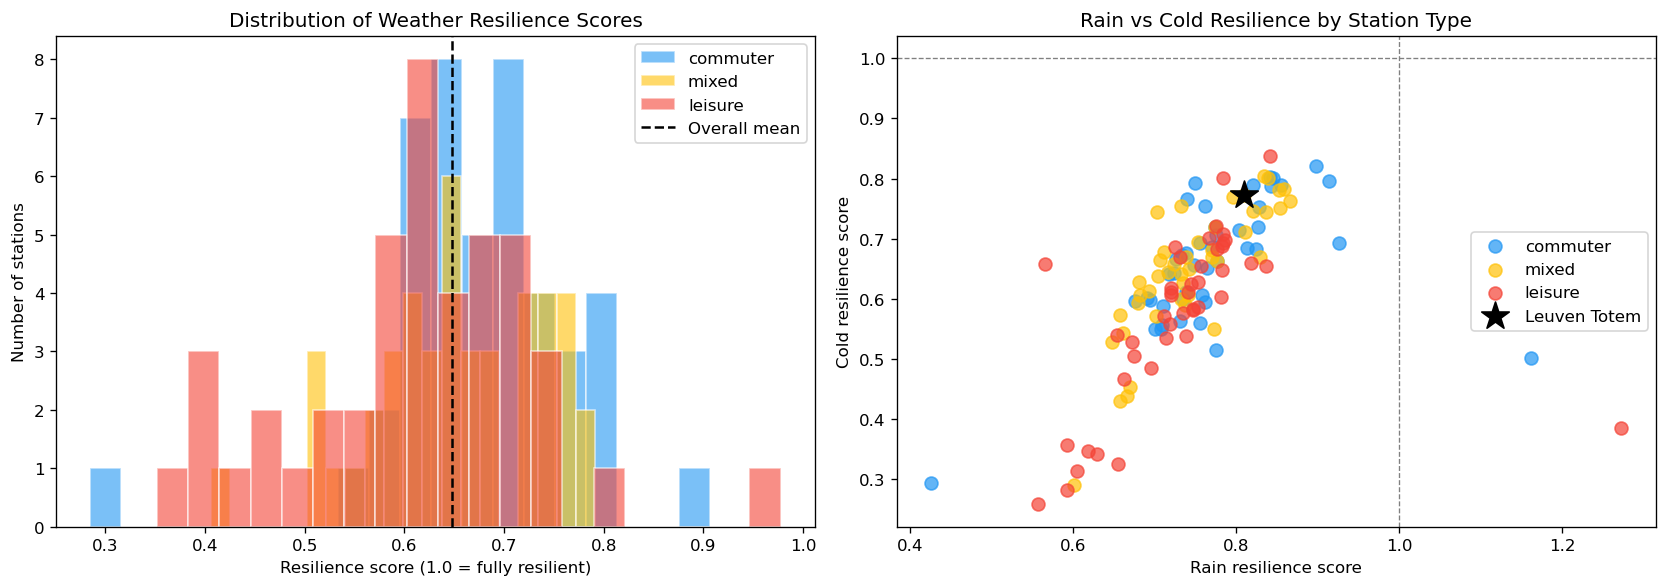

fig22 saved.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram by site type
ax = axes[0]
for st, color in COLORS.items():
    sub = resilience[resilience["site_type"] == st]["resilience_score"]
    ax.hist(sub, bins=20, alpha=0.6, color=color, label=st, edgecolor="white")
ax.axvline(resilience["resilience_score"].mean(),
           color="black", linestyle="--", label="Overall mean")
ax.set_xlabel("Resilience score (1.0 = fully resilient)")
ax.set_ylabel("Number of stations")
ax.set_title("Distribution of Weather Resilience Scores")
ax.legend()

# Right: rain vs cold resilience scatter
ax = axes[1]
for st, color in COLORS.items():
    sub = resilience[resilience["site_type"] == st]
    ax.scatter(sub["resilience_rain"], sub["resilience_cold"],
               color=color, alpha=0.7, label=st, s=60)
ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(1.0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Rain resilience score")
ax.set_ylabel("Cold resilience score")
ax.set_title("Rain vs Cold Resilience by Station Type")
ax.legend()

lt = resilience[resilience["site ID"] == 107]
axes[1].scatter(lt["resilience_rain"], lt["resilience_cold"],
                color="black", marker="*", s=300, zorder=5,
                label="Leuven Totem")
axes[1].legend()

fig.tight_layout()
fig.savefig(FIGS / "fig22_resilience_distribution.png", dpi=150)
plt.show()
print("fig22 saved.")

### fig23 — Priority Map

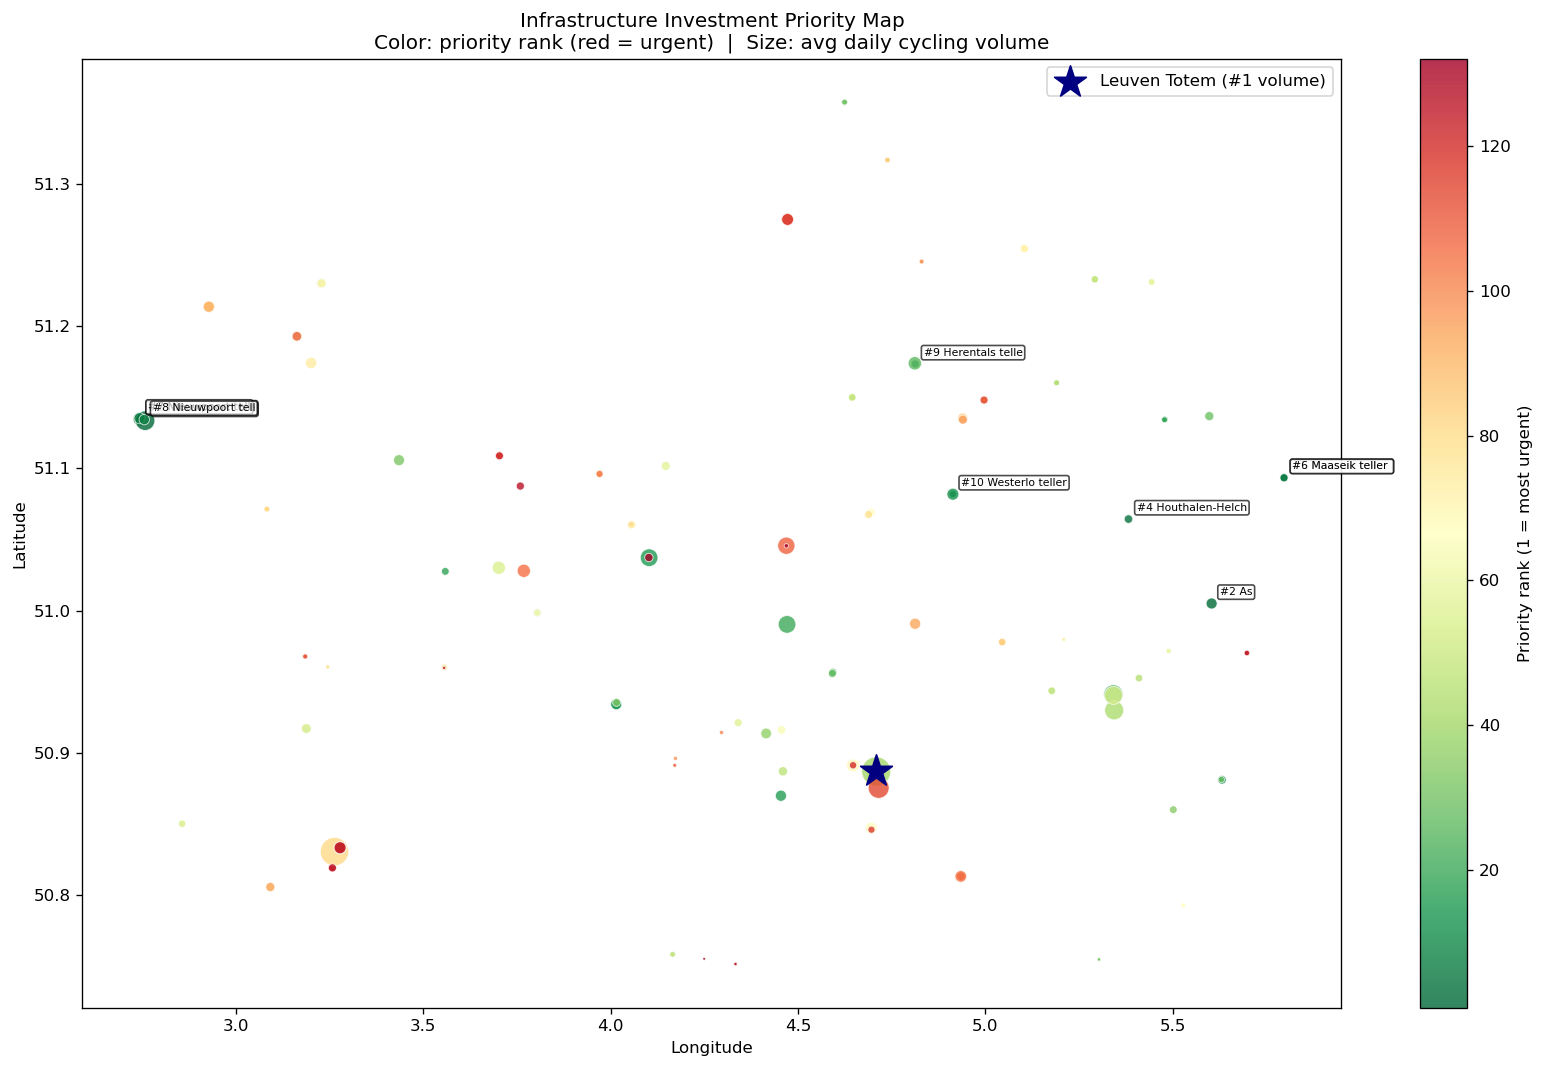

fig23 saved.


In [7]:
fig, ax = plt.subplots(figsize=(14, 9))

cmap       = plt.cm.RdYlGn_r
norm_color = mcolors.Normalize(
    vmin=resilience["priority_rank"].min(),
    vmax=resilience["priority_rank"].max(),
)

scatter = ax.scatter(
    resilience["lon"],
    resilience["lat"],
    c=resilience["priority_rank"],
    cmap=cmap,
    norm=norm_color,
    s=resilience["avg_daily"] / 15,
    alpha=0.8,
    edgecolors="white",
    linewidths=0.5,
)

top10 = resilience.sort_values("priority_rank").head(10)
for _, row in top10.iterrows():
    ax.annotate(
        f"#{int(row['priority_rank'])} {row['naam'][:15]}",
        (row["lon"], row["lat"]),
        fontsize=6.5,
        xytext=(5, 5),
        textcoords="offset points",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7),
    )

lt = resilience[resilience["site ID"] == 107]
ax.scatter(lt["lon"], lt["lat"], color="navy", marker="*",
           s=400, zorder=10, label="Leuven Totem (#1 volume)")

plt.colorbar(scatter, ax=ax, label="Priority rank (1 = most urgent)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(
    "Infrastructure Investment Priority Map\n"
    "Color: priority rank (red = urgent)  |  Size: avg daily cycling volume",
    fontsize=12,
)
ax.legend()
fig.tight_layout()
fig.savefig(FIGS / "fig23_priority_map.png", dpi=150)
plt.show()
print("fig23 saved.")

### fig24 — Top 15 Sensitive vs Top 15 Resilient

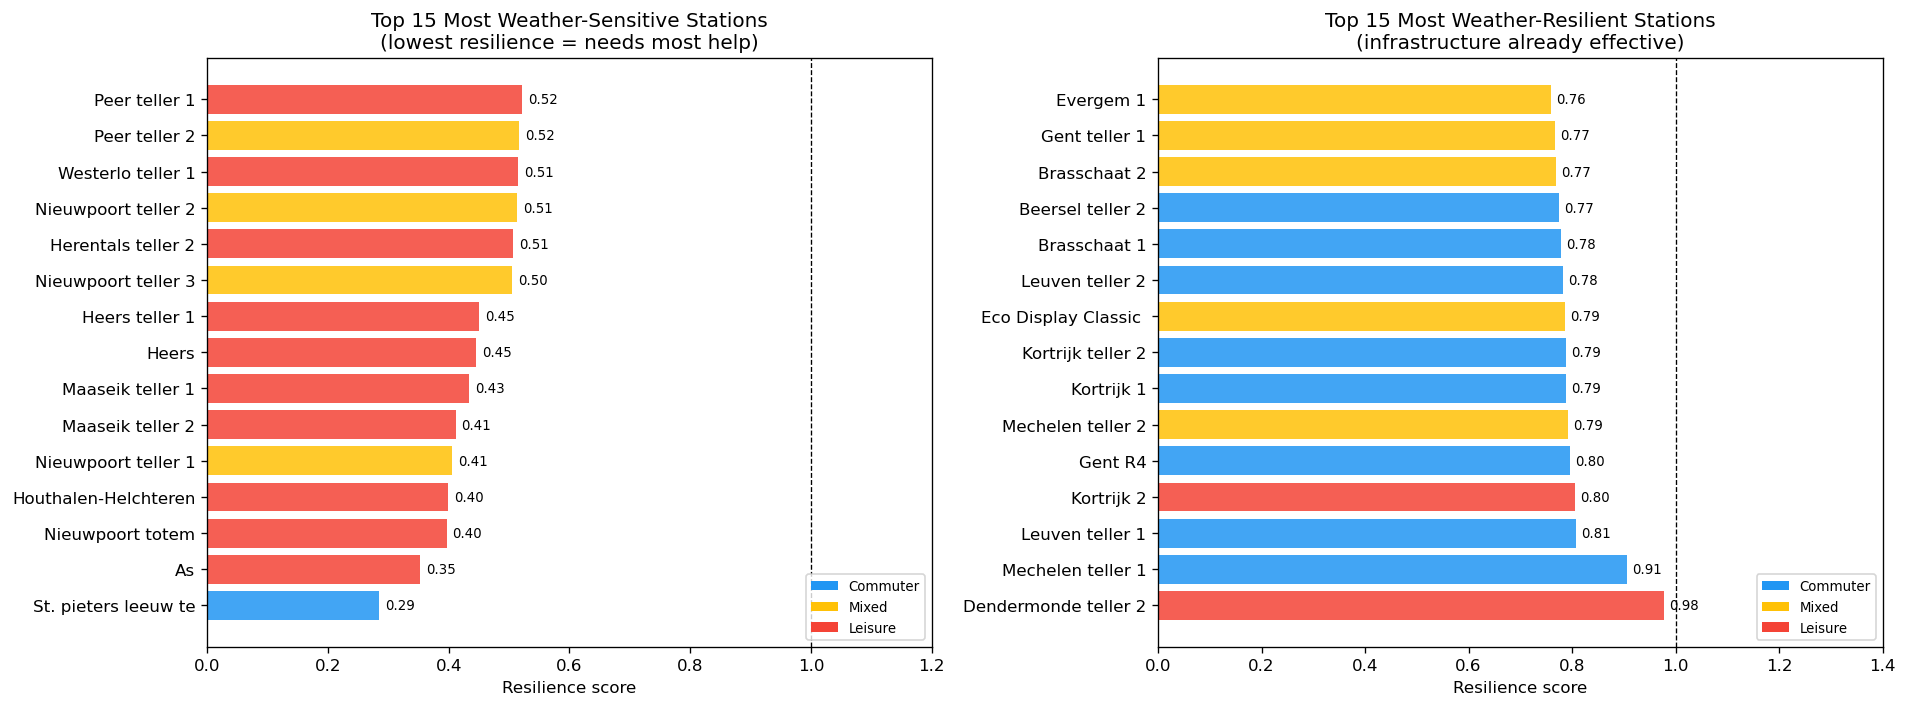

fig24 saved.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

legend_elements = [
    Patch(facecolor=COLORS["commuter"], label="Commuter"),
    Patch(facecolor=COLORS["mixed"],    label="Mixed"),
    Patch(facecolor=COLORS["leisure"],  label="Leisure"),
]

# Left: top 15 most sensitive
ax = axes[0]
sensitive_15 = resilience.head(15).sort_values("resilience_score", ascending=True)
colors_s = [COLORS.get(st, "gray") for st in sensitive_15["site_type"]]
bars = ax.barh(sensitive_15["naam"].str[:20],
               sensitive_15["resilience_score"],
               color=colors_s, alpha=0.85)
ax.axvline(1.0, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("Resilience score")
ax.set_title("Top 15 Most Weather-Sensitive Stations\n"
             "(lowest resilience = needs most help)")
ax.set_xlim(0, 1.2)
for bar, val in zip(bars, sensitive_15["resilience_score"]):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}", va="center", fontsize=8)
ax.legend(handles=legend_elements, loc="lower right", fontsize=8)

# Right: top 15 most resilient
ax = axes[1]
resilient_15 = resilience.nlargest(15, "resilience_score").sort_values(
    "resilience_score", ascending=False)
colors_r = [COLORS.get(st, "gray") for st in resilient_15["site_type"]]
bars = ax.barh(resilient_15["naam"].str[:20],
               resilient_15["resilience_score"],
               color=colors_r, alpha=0.85)
ax.axvline(1.0, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("Resilience score")
ax.set_title("Top 15 Most Weather-Resilient Stations\n"
             "(infrastructure already effective)")
ax.set_xlim(0, 1.4)
for bar, val in zip(bars, resilient_15["resilience_score"]):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}", va="center", fontsize=8)
ax.legend(handles=legend_elements, loc="lower right", fontsize=8)

fig.tight_layout()
fig.savefig(FIGS / "fig24_sensitive_vs_resilient.png", dpi=150)
plt.show()
print("fig24 saved.")

## 6. Save Resilience Results

In [9]:
resilience.to_parquet(PROCESSED / "station_resilience.parquet", index=False)
print(f"Saved: {PROCESSED / 'station_resilience.parquet'}")

Saved: /Users/queena/Documents/KU Leuven/Study material/Semester 1.2/Modern Analysis/Project/mda-cycling-weather-group6/data/processed/station_resilience.parquet


## 7. Final Summary

In [10]:
n_stations = resilience["site ID"].nunique()
r_mean     = resilience["resilience_score"].mean()
r_median   = resilience["resilience_score"].median()
r_min      = resilience["resilience_score"].min()
r_max      = resilience["resilience_score"].max()
most_sens  = resilience.loc[resilience["resilience_score"].idxmin(), "naam"]
most_resil = resilience.loc[resilience["resilience_score"].idxmax(), "naam"]

by_type_s  = resilience.groupby("site_type")["resilience_score"].mean()

c_morn_pct = ct.loc["commuter", "morning_rain_effect"] * 100
l_morn_pct = ct.loc["leisure",  "morning_rain_effect"] * 100
rel_diff   = (c_morn_pct - l_morn_pct) / abs(l_morn_pct) * 100

top5 = resilience.sort_values("priority_rank").head(5)

lt_row   = resilience[resilience["site ID"] == 107].iloc[0]

print("=" * 52)
print("SENSITIVITY ANALYSIS SUMMARY")
print("=" * 52)
print(f"Stations analysed: {n_stations} (well-covered)")
print()
print("Overall resilience score distribution:")
print(f"  Mean   : {r_mean:.3f}")
print(f"  Median : {r_median:.3f}")
print(f"  Min    : {r_min:.3f}  (most sensitive: {most_sens})")
print(f"  Max    : {r_max:.3f}  (most resilient: {most_resil})")
print()
print("Resilience by site type:")
for st in ["commuter", "mixed", "leisure"]:
    tag = " (most resilient \u2713)" if st == "commuter" else \
          " (most sensitive \u2713)" if st == "leisure" else ""
    print(f"  {st:10s}: {by_type_s[st]:.3f}{tag}")
print()
print("Commute-period rain effect:")
print(f"  commuter morning rain : {c_morn_pct:+.1f}%")
print(f"  leisure  morning rain : {l_morn_pct:+.1f}%")
print(f"  \u2192 commuters {abs(rel_diff):.1f}% less affected during morning commute")
print()
print("Top 5 Priority Stations for Investment:")
for _, row in top5.iterrows():
    print(f"  #{int(row['priority_rank'])}  {row['naam'][:25]:<25} "
          f"({row['gemeente']}) — "
          f"resilience: {row['resilience_score']:.3f}, "
          f"avg: {row['avg_daily']:.0f}/day")
print()
print("Leuven Totem (site ID 107):")
print(f"  Resilience score : {lt_row['resilience_score']:.3f}")
print(f"  Sensitivity rank : #{int(lt_row['sensitivity_rank'])} / {n_stations}")
print(f"  Priority rank    : #{int(lt_row['priority_rank'])} / {n_stations}")
print(f"  Rain resilience  : {lt_row['resilience_rain']:.3f}")
print(f"  Cold resilience  : {lt_row['resilience_cold']:.3f}")
print()
print("Figures saved:")
for fn in ["fig22_resilience_distribution.png",
           "fig23_priority_map.png",
           "fig24_sensitive_vs_resilient.png"]:
    print(f"  {FIGS / fn}")
print("=" * 52)

SENSITIVITY ANALYSIS SUMMARY
Stations analysed: 132 (well-covered)

Overall resilience score distribution:
  Mean   : 0.648
  Median : 0.651
  Min    : 0.285  (most sensitive: St. pieters leeuw teller 2)
  Max    : 0.978  (most resilient: Dendermonde teller 2)

Resilience by site type:
  commuter  : 0.679 (most resilient ✓)
  mixed     : 0.652
  leisure   : 0.613 (most sensitive ✓)

Commute-period rain effect:
  commuter morning rain : -31.9%
  leisure  morning rain : -38.0%
  → commuters 16.1% less affected during morning commute

Top 5 Priority Stations for Investment:
  #1  Nieuwpoort teller 1       (Nieuwpoort) — resilience: 0.406, avg: 2049/day
  #2  As                        (As) — resilience: 0.352, avg: 651/day
  #3  Nieuwpoort totem          (Nieuwpoort) — resilience: 0.397, avg: 1005/day
  #4  Houthalen-Helchteren      (Houthalen-Helchteren) — resilience: 0.399, avg: 392/day
  #5  Maaseik teller 2          (Maaseik) — resilience: 0.411, avg: 379/day

Leuven Totem (site ID 107